# Solow-Swan Growth Model
Let us start the lecture by taking a look at the differences in GDP per capita across countries. Throughout this lecture we will use the data from the 11.0 version of the [Penn World Table](https://www.rug.nl/ggdc/productivity/pwt/?lang=en) database.

In [1]:
# Import numerical computations library
import numpy as np

# Import dataframe management library
import pandas as pd

# Import statistics library
import statsmodels.api as sm

# Import statistics library, allows R-like regression syntax
import statsmodels.formula.api as smf

# Import plotting library
import matplotlib.pyplot as plt

In [2]:
# Restore old behavior of rounding default axis ranges
import matplotlib as mpl

mpl.rcParams['axes.autolimit_mode'] = 'round_numbers'
mpl.rcParams['axes.xmargin'] = 0
mpl.rcParams['axes.ymargin'] = 0

In [3]:
from pathlib import Path

# Run from this notebook's folder, or point DATA_DIR to the data folder.
pwt = pd.read_stata('data/pwt110.dta')
START_YEAR = int(pwt['year'].min())
END_YEAR = min(2023, int(pwt['year'].max()))
pwt = pwt.loc[pwt['year'].between(START_YEAR, END_YEAR)].copy()
print(f'PWT 11.0: {START_YEAR}–{END_YEAR}; GDP values in 2021 US dollars')
pwt.tail()


PWT 11.0: 1950–2023; GDP values in 2021 US dollars


,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
13685,ZWE,Zimbabwe,US Dollar,2019,46541.140625,45106.468750,15.271368,5.272343,1903.71,2.713408,...,0.189066,-0.242234,0.038880,0.501244,0.534841,0.345942,0.505318,0.441230,0.339268,1.346716
13686,ZWE,Zimbabwe,US Dollar,2020,45985.085938,45983.898438,15.526888,5.206007,1889.45,2.746586,...,0.110438,-0.165574,0.029654,0.500685,0.519637,0.290690,0.772591,0.680202,0.324105,1.353769
13687,ZWE,Zimbabwe,US Dollar,2021,45625.347656,44440.199219,15.797210,5.298346,2011.57,2.770661,...,0.172298,-0.279770,0.024442,0.616105,0.549380,0.301370,0.558099,0.497615,0.347739,1.064607
13688,ZWE,Zimbabwe,US Dollar,2022,50148.527344,48054.238281,16.069056,5.344455,2172.04,2.795292,...,0.220504,-0.391468,0.021712,0.660731,0.478931,0.280778,0.487665,0.432867,0.301817,1.006796
13689,ZWE,Zimbabwe,US Dollar,2023,52258.898438,50540.847656,16.340822,5.504774,2311.02,2.820498,...,0.179567,-0.308382,0.015704,0.736836,0.507688,0.307323,0.505070,0.474047,0.308811,1.030187


We will be using (among others) the following time series from the PWT dataset:

* **rgdpe** - Expenditure-side real GDP at chained PPPs (in mil. 2021US\$): to compare relative living standards across countries and over time
* **rgdpo** - Output-side real GDP at chained PPPs (in mil. 2021US\$): to compare relative productive capacity across countries and over time
* **pop** - Population (in millions)
* **emp** - Number of persons engaged (in millions)
* **hc** - Human capital index, based on years of schooling and returns to education
* **csh_i** - Share of gross capital formation at current PPPs
The description of other variables can be found in the Legend sheet of the PWT excel file:
https://www.rug.nl/ggdc/productivity/pwt/

In [4]:
# Observations for given year, show first 5
pwt[pwt['year']==2010].head(5)

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
60,ABW,Aruba,Aruban Guilder,2010,4436.711426,4445.569824,0.100114,0.046524,NaN,NaN,...,0.616339,-0.836055,-6.830694e-07,0.670057,0.412195,0.576176,0.582709,0.536777,0.308778,0.356775
134,AGO,Angola,Kwanza,2010,154504.140625,179786.000000,23.294825,11.168817,2083.48,1.417133,...,0.651220,-0.170396,-2.239611e-01,0.624092,0.455352,0.574733,0.462673,0.557157,0.307212,0.454283
208,AIA,Anguilla,East Caribbean Dollar,2010,459.244751,453.184204,0.013345,NaN,NaN,NaN,...,0.547647,-1.038301,-1.387022e-09,0.670709,0.437008,0.528855,0.622078,0.480208,0.312885,NaN
282,ALB,Albania,Lek,2010,31252.564453,32393.847656,2.928722,0.912912,2119.70,2.904078,...,0.090179,-0.308366,6.020230e-02,0.436880,0.411531,0.186174,0.534224,0.463940,0.298015,0.215791
356,ARE,United Arab Emirates,UAE Dirham,2010,649343.125000,730709.562500,6.938363,5.297270,2615.65,2.717433,...,0.571642,-0.486612,1.423015e-01,0.524174,0.366899,0.568869,0.507659,0.545163,0.294005,NaN


In [5]:
# Sample 10 observations for given year
pwt[pwt['year']==2010].sample(n=10, random_state=1)

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
1244,BGR,Bulgaria,Bulgarian Lev,2010,1.402981e+05,1.409200e+05,7.437599,3.254047,1644.84,3.082860,...,0.257916,-0.368754,6.190135e-02,0.416244,0.416524,0.227172,0.588725,0.506716,0.288244,0.998612
13306,VGB,British Virgin Islands,US Dollar,2010,1.199055e+03,1.061276e+03,0.027675,0.014429,NaN,NaN,...,2.191320,-2.078363,-1.118568e-03,0.915064,0.892993,1.011144,0.628079,0.459224,0.862160,2.401289
4944,GNB,Guinea-Bissau,CFA Franc BCEAO,2010,2.409878e+03,2.578370e+03,1.566347,0.418646,NaN,NaN,...,0.136462,-0.241277,-1.337683e-16,0.384908,0.413390,0.242982,0.501471,0.501840,0.267729,NaN
3020,CPV,Cabo Verde,Cabo Verde Escudo,2010,3.867499e+03,3.934040e+03,0.509784,0.177297,NaN,NaN,...,0.019741,-0.376432,1.251457e-01,0.462546,0.508052,0.459981,0.608140,0.500581,0.373466,0.265202
12344,TKM,Turkmenistan,Turkmenistan Manat,2010,9.734691e+04,1.110206e+05,5.564356,2.781924,2159.71,NaN,...,0.052146,-0.084467,4.359005e-01,0.426958,0.408686,0.068508,0.485451,0.552266,0.199419,NaN
11530,SVN,Slovenia,Euro,2010,6.920795e+04,6.643862e+04,2.044612,0.954647,1680.33,3.391089,...,0.653093,-0.787755,5.588184e-02,0.720462,0.620006,0.723200,0.593579,0.535551,0.513727,0.536556
7238,LBR,Liberia,US Dollar,2010,3.575710e+03,4.033558e+03,4.058890,0.752331,NaN,1.724602,...,0.059324,-0.265135,-1.643545e-16,0.381449,0.402420,0.377134,0.605269,0.562652,0.248242,NaN
13158,VCT,St. Vincent and the Grenadines,East Caribbean Dollar,2010,1.379718e+03,1.288154e+03,0.109959,0.037271,NaN,NaN,...,0.234862,-0.655496,5.425533e-02,0.554881,0.579800,0.404559,0.651576,0.487104,0.384444,NaN
2650,CMR,Cameroon,CFA Franc BEAC,2010,7.059595e+04,7.146400e+04,19.668066,7.558790,2139.70,1.869879,...,0.096188,-0.141364,2.061040e-02,0.379892,0.474741,0.342916,0.570025,0.513354,0.342475,0.646615
4056,ESP,Spain,Euro,2010,1.852193e+06,1.817060e+06,46.840471,19.477291,1703.21,2.803053,...,0.227637,-0.311961,3.864254e-02,0.810914,0.625609,0.878756,0.604872,0.566968,0.528528,0.653424


In [6]:
# Observations for given country, show last 10
pwt[pwt['country']=='Poland'].tail(10)

,countrycode,country,currency_unit,year,rgdpe,rgdpo,pop,emp,avh,hc,...,csh_x,csh_m,csh_r,pl_c,pl_i,pl_g,pl_x,pl_m,pl_n,pl_k
10054,POL,Poland,Zloty,2014,1105012.375,1098158.750,38.265113,15.801454,1822.30,3.340265,...,0.312867,-0.351492,0.009607,0.499919,0.577336,0.422308,0.648055,0.584928,0.431554,0.963976
10055,POL,Poland,Zloty,2015,1187056.000,1155269.750,38.266314,16.052399,1829.16,3.357166,...,0.292065,-0.316383,0.010752,0.415714,0.474206,0.343632,0.589574,0.530921,0.347259,0.804403
10056,POL,Poland,Zloty,2016,1218538.500,1179819.500,38.263265,16.192057,1831.36,3.374153,...,0.291491,-0.307935,0.012699,0.399563,0.456611,0.330597,0.581253,0.527984,0.332814,0.724561
10057,POL,Poland,Zloty,2017,1262828.125,1228854.625,38.254959,16.402636,1811.62,3.382678,...,0.306368,-0.333730,0.021891,0.436638,0.465200,0.348117,0.597686,0.540429,0.342804,0.746089
10058,POL,Poland,Zloty,2018,1308172.250,1275970.375,38.241071,16.488451,1787.33,3.391225,...,0.334622,-0.373652,0.030124,0.471678,0.495337,0.384611,0.620548,0.568219,0.366750,0.779356
10059,POL,Poland,Zloty,2019,1431693.625,1389263.750,38.225885,16.882605,1796.51,3.399794,...,0.308140,-0.331593,0.027801,0.435450,0.460756,0.363019,0.595303,0.541752,0.342754,0.746383
10060,POL,Poland,Zloty,2020,1425778.250,1365882.000,38.171012,17.247025,1779.21,3.408384,...,0.306463,-0.321979,0.030952,0.436644,0.469992,0.370842,0.606077,0.542057,0.346559,0.804627
10061,POL,Poland,Zloty,2021,1507236.625,1457955.250,38.040302,17.776213,1827.92,3.435005,...,0.339726,-0.369338,0.028908,0.472531,0.486312,0.391130,0.630381,0.575863,0.363466,0.850430
10062,POL,Poland,Zloty,2022,1553447.625,1527832.000,38.385739,17.751879,1818.44,3.462086,...,0.371345,-0.402983,0.028619,0.466128,0.453840,0.384230,0.606717,0.572385,0.357972,0.779190
10063,POL,Poland,Zloty,2023,1572956.750,1519751.375,38.762844,18.014509,1806.92,3.489637,...,0.366482,-0.375406,0.033557,0.541183,0.513044,0.452606,0.672124,0.621964,0.396007,0.812818


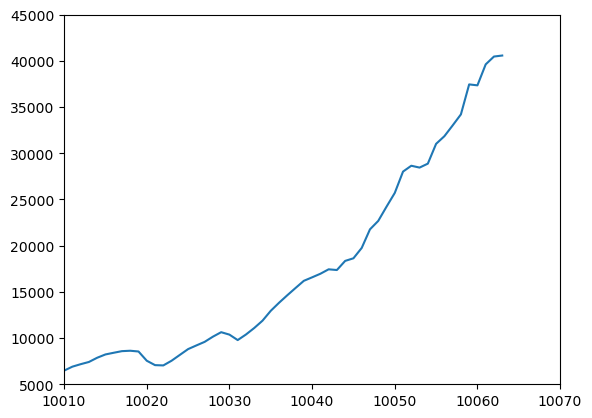

In [7]:
# Plot real GDP per capita series for Poland, note x-axis behavior
(pwt[pwt['country']=='Poland']['rgdpe'] / 
 pwt[pwt['country']=='Poland']['pop']).plot()
plt.show()

In [8]:
# Modify the dataset so that it is easier to work with

# Store country names and codes for later use
countries = pwt['country']
countries = countries.drop_duplicates()

countrycodes = pwt['countrycode']
countrycodes = countrycodes.drop_duplicates()

# Set MultiIndex (Index becomes country&year couple)
pwt.set_index(['country', 'year'], inplace=True)
pwt.sort_index(inplace=True)
pwt.tail(5)

countrycode currency_unit         rgdpe         rgdpo  \
country  year                                                         
Zimbabwe 2019         ZWE     US Dollar  46541.140625  45106.468750   
         2020         ZWE     US Dollar  45985.085938  45983.898438   
         2021         ZWE     US Dollar  45625.347656  44440.199219   
         2022         ZWE     US Dollar  50148.527344  48054.238281   
         2023         ZWE     US Dollar  52258.898438  50540.847656   

                     pop       emp      avh        hc          ccon  \
country  year                                                         
Zimbabwe 2019  15.271368  5.272343  1903.71  2.713408  39602.753906   
         2020  15.526888  5.206007  1889.45  2.746586  41572.535156   
         2021  15.797210  5.298346  2011.57  2.770661  41325.707031   
         2022  16.069056  5.344455  2172.04  2.795292  46625.746094   
         2023  16.340822  5.504774  2311.02  2.820498  46345.812500   

                        cda  ...     csh_x     csh_m     csh_r      pl_c  \
country  year                ...                                           
Zimbabwe 2019  45432.328125  ...  0.189066 -0.242234  0.038880  0.501244   
         2020  47053.406250  ...  0.110438 -0.165574  0.029654  0.500685   
         2021  48130.085938  ...  0.172298 -0.279770  0.024442  0.616105   
         2022  54859.515625  ...  0.220504 -0.391468  0.021712  0.660731   
         2023  56080.398438  ...  0.179567 -0.308382  0.015704  0.736836   

                   pl_i      pl_g      pl_x      pl_m      pl_n      pl_k  
country  year                                                              
Zimbabwe 2019  0.534841  0.345942  0.505318  0.441230  0.339268  1.346716  
         2020  0.519637  0.290690  0.772591  0.680202  0.324105  1.353769  
         2021  0.549380  0.301370  0.558099  0.497615  0.347739  1.064607  
         2022  0.478931  0.280778  0.487665  0.432867  0.301817  1.006796  
         2023  0.507688  0.307323  0.505070  0.474047  0.308811  1.030187  

[5 rows x 49 columns]

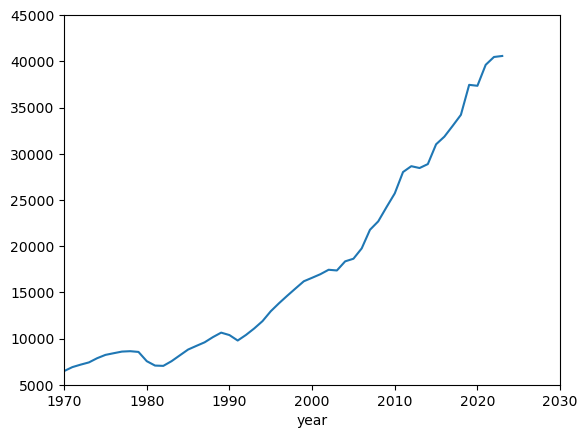

In [9]:
# Again plot real GDP per capita series for Poland, note x-axis behavior
(pwt.loc['Poland']['rgdpe'] / pwt.loc['Poland']['pop']).plot()
plt.show()

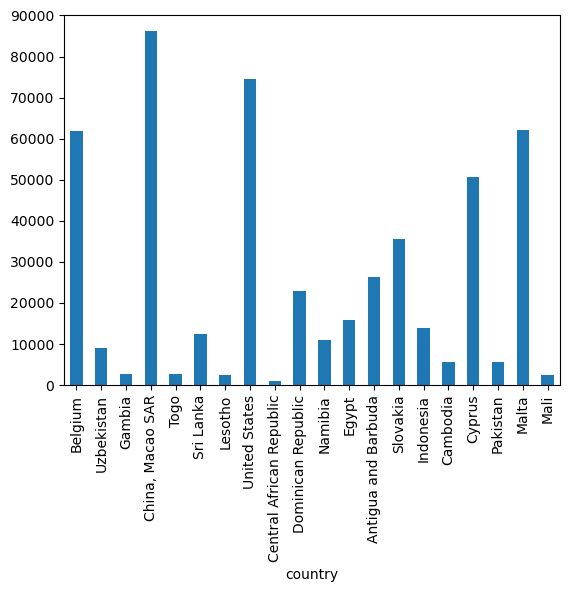

In [10]:
# Plot GDP per capita in 2023 for random 20 countries
(pwt.xs(END_YEAR, level='year')['rgdpe'] / 
 pwt.xs(END_YEAR, level='year')['pop']).sample(20, random_state=1).plot.bar()
plt.show()

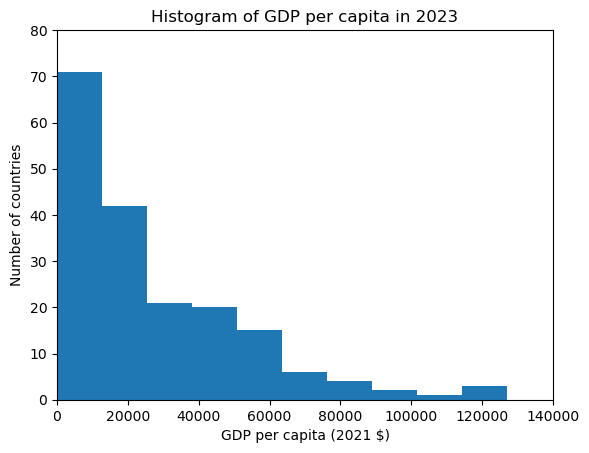

In [11]:
# Extract data for GDP per capita in 2023
gdp_pc_latest = (pwt.xs(END_YEAR, level='year')['rgdpe']/
               pwt.xs(END_YEAR, level='year')['pop'])

gdp_pc_latest = gdp_pc_latest.replace([np.inf, -np.inf], np.nan).dropna()
gdp_pc_latest = gdp_pc_latest[gdp_pc_latest > 0]

# Plot histogram
plt.hist(gdp_pc_latest)

plt.title('Histogram of GDP per capita in 2023')
plt.xlabel(r'GDP per capita (2021 \$)')
plt.ylabel('Number of countries')

plt.show()

In [12]:
min_gdp=(round(gdp_pc_latest.min(),2),gdp_pc_latest.idxmin())
min_gdp

(89.33, 'Venezuela (Bolivarian Republic of)')

In [13]:
max_gdp=(round(gdp_pc_latest.max(),2),gdp_pc_latest.idxmax())
max_gdp

(127135.91, 'Qatar')

In [14]:
# List countries with very high GDP per capita
highgdp=gdp_pc_latest[gdp_pc_latest > 55000]

In [15]:
# Listing countries by GDP per capita
highgdp.sort_values(ascending=False)

country
Qatar                   127135.913849
Luxembourg              118582.888819
Ireland                 116784.748000
Singapore               112778.681537
Bermuda                  93087.199976
Norway                   89075.053128
China, Macao SAR         86310.910212
United Arab Emirates     84881.818462
Brunei Darussalam        84525.510324
Switzerland              82203.390237
Cayman Islands           76192.265178
United States            74653.676930
Iceland                  68678.596373
Netherlands              68498.188810
Denmark                  65313.922504
Taiwan                   65004.351926
Austria                  62978.995839
Australia                62890.569414
Sweden                   62536.043474
Malta                    62005.748950
Belgium                  61771.635966
China, Hong Kong SAR     61070.115498
Germany                  59853.647322
Saudi Arabia             56815.387052
Canada                   55111.910309
dtype: float64

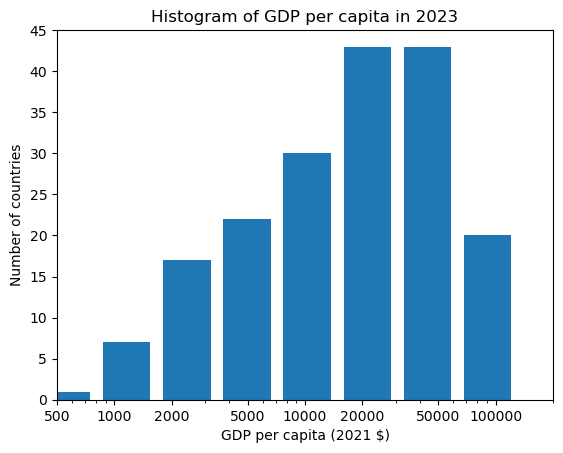

In [16]:
# Data is highly skewed -- maybe better display in logarithms
# np.logspace (start, stop, num=50, endpoint=True, base=10.0, dtype=None
#, axis=0) - Return numbers spaced evenly on a log scale

log_bins_2023 = np.logspace(np.log(np.min(gdp_pc_latest)),
                            np.log(np.max(gdp_pc_latest)),
                            num=1+10, base=np.e)

plt.hist(gdp_pc_latest, bins=log_bins_2023, histtype='bar', rwidth=0.8)

plt.xscale('log')

plt.xlim(500, 200000)

plt.xticks([500, 1000, 2000, 5000, 10000, 20000, 50000, 100000], 
           [500, 1000, 2000, 5000, 10000, 20000, 50000, 100000])

plt.title('Histogram of GDP per capita in 2023')
plt.xlabel(r'GDP per capita (2021 \$)')
plt.ylabel('Number of countries')

plt.show()

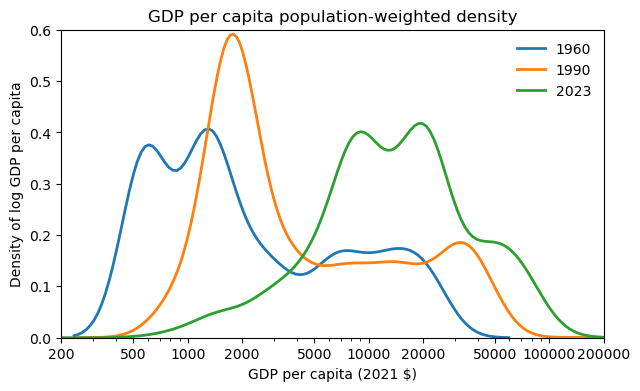

In [17]:
# Plot the population-weighted distribution of GDP per capita in given years

plt.subplots(figsize = (7, 4))

for i, year in enumerate([1960, 1990, END_YEAR]):
    sl = pwt.xs(year, level='year').dropna(subset=['rgdpe','pop'])
    # Dataframe.xs: Return cross-section from the Series/DataFrame. 
    # In our case returns rgdpe and pop by 1960,1997,2023 years.
    # dropna remove missing values
    sl = sl.loc[(sl['rgdpe'] > 0) & (sl['pop'] > 0)]

    weighted = sm.nonparametric.KDEUnivariate(np.log(sl['rgdpe']/sl['pop']))
# kernel density estimation (KDE) is a non-parametric way to estimate the
# probability density function of a random variable. (Log of GDP per capita in our case)    
    weighted.fit(bw=0.3, fft=False, weights=sl['pop'])
    plt.plot(np.exp(weighted.support), 
             weighted.density, 
             lw=2, label='{0}'.format(year))

plt.xscale('log')

plt.xticks([200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000], 
           [200, 500, 1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000])
    
plt.legend(frameon=False)

plt.xlim(2e2, 2e5)

plt.title('GDP per capita population-weighted density')
plt.xlabel(r'GDP per capita (2021 \$)')
plt.ylabel('Density of log GDP per capita')

plt.show()

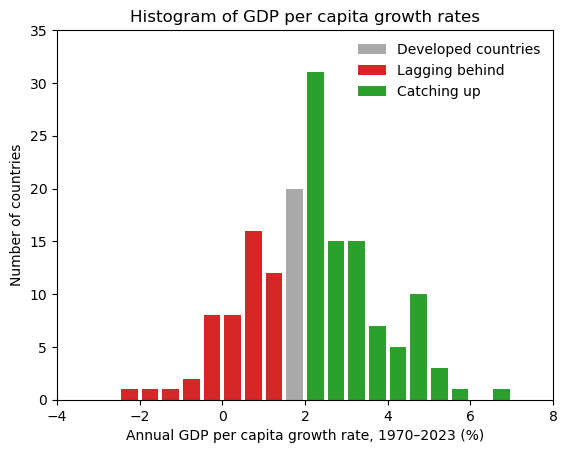

In [18]:
# Histogram bands use explicit edges and non-overlapping observations.
x_70 = pwt.xs(1970, level='year')['rgdpe'] / pwt.xs(1970, level='year')['pop']
x_latest = pwt.xs(END_YEAR, level='year')['rgdpe'] / pwt.xs(END_YEAR, level='year')['pop']
g = 100 * ((x_latest / x_70) ** (1 / (END_YEAR - 1970)) - 1)
g = g.replace([np.inf, -np.inf], np.nan).dropna()
low_edge = min(-10, np.floor(g.min() / .5) * .5)
high_edge = max(10, np.ceil(g.max() / .5) * .5)
plt.hist(g.dropna(), np.arange(1.5, 2.5, 0.5), histtype='bar', rwidth=0.8, fc='darkgrey', label='Developed countries')
plt.hist(g.dropna(), np.arange(-10, 2, 0.5), histtype='bar', rwidth=0.8, fc='C3', label='Lagging behind')
plt.hist(g.dropna(), np.arange(2, 10, 0.5), histtype='bar', rwidth=0.8, fc='C2', label='Catching up')
plt.xlim(-4, 8)
plt.title('Histogram of GDP per capita growth rates')
plt.xlabel(f'Annual GDP per capita growth rate, 1970–{END_YEAR} (%)')
plt.ylabel('Number of countries')
plt.legend(frameon=False)
plt.show()


In [19]:
# Display the name of the countries with the
# lowest and the highest GDP per capita growth between 1970-2023
[round(g.min(),2),g.idxmin(), round(g.max(),2),g.idxmax()]

[-8.57, 'Venezuela (Bolivarian Republic of)', 6.75, 'China']

## We want to explain the following set of facts:

* There is high dispersion in GDP per capita across countries
* The developed countries keep growing
* Some (but not all) developing countries (notably China and India) are catching up to the developed countries

## Solow-Swan Model

Authors: [Robert Solow (1956)](https://academic.oup.com/qje/article-abstract/70/1/65/1903777) and [Trevor Swan (1956)](https://onlinelibrary.wiley.com/doi/abs/10.1111/j.1475-4932.1956.tb00434.x)

Assumptions and simplifications:

* One sector economy: produces a single good that can be either consumed or invested
* Complete information, no externalities
* Markets for the final good and factors of production are perfectly competitive
* Closed economy and no government
* Two types of representative agents: firms and households
* Firms optimize, while households do not (save a fixed fraction of their income)
* Households own capital and labor and rent them to the firms
* Output is produced according to a neoclassical production function


A consequence of the closed economy and no government assumption is that private savings are equal to private investment. This is an accounting identity and says nothing about any causal relationships between savings and investment.

Start from the national accounting identity and assume no government ($G=0$ ) and no international trade ($NX=0$):
$$ Y=C+I+\underbrace{G}_{0}+\underbrace{NX}_{0} \quad   \rightarrow  \quad Y=C+I$$

Then consider the disposition of households' disposable income  $Y^{d}$  between consumption and savings. If there is no government, taxes  $T=0$  and disposable income is equal to the economy's output:
$$ Y^{d}=C+S \quad \textrm{and} \quad Y^{d}=Y-\underbrace{T}_{0} \quad \rightarrow  \quad Y=C+S$$

Together those two accounting exercises yield the result that savings are equal to investment:
$$ Y=C+I \quad \textrm{and} \quad Y=C+S \quad \rightarrow  \quad I=S$$

### Three core equations

1. Capital accumulation (accounting identity):

$$K_{t+1}=I_{t}+(1-\delta).K_{t}$$


2. Investment / saving decisions: households save a constant fraction  𝑠  of their income (behavioral assumption):

$$ I_{t}=S_{t}=s.Y_{t}$$


3. Output is produced using capital  $K$  and labor  $L$ , using technology $A$, and the production function $F$ is neoclassical (functional restriction):

$$Y_{t}=F(K_{t},L_{t},A_{t})$$


### Neoclassical production function

A production function describes how capital $K$ and labor $L$, using technology $A$, is transformed into output $Y$:

$$ Y=F(K,L,A) $$

A neoclassical production function $F$ has the following properties:

* Continuous and at least twice differentiable


* Constant returns to scale in $K$ and $L$. Multiplying both capital and labor inputs by a certain proportion $z$ translates to multiplying produced output by that same proportion $z$:

$$ F(z.K,z.L,A)=z.F(K,L,A)=z.Y \quad \textrm{for all} \quad z>0$$


* Positive but diminishing marginal products of $K$ and $L$:

\begin{align}
\frac{\partial F \left( K, L, A \right)}{\partial K} \equiv F_{K} \left( K, L, A \right) > 0 \quad &\text{and} \quad 
\frac{\partial^{2} F \left( K, L, A \right)}{\partial K^{2}} \equiv F_{KK} \left( K, L, A \right) < 0 \\
\frac{\partial F \left( K, L, A \right)}{\partial L} \equiv F_{L} \left( K, L, A \right) > 0 \quad &\text{and} \quad 
\frac{\partial^{2} F \left( K, L, A \right)}{\partial L^{2}} \equiv F_{LL} \left( K, L, A \right) < 0
\end{align}


* (Optional) [Inada (1963)](https://www.jstor.org/stable/2295809) conditions:

\begin{align}
\lim_{K \to 0} F_{K} \left( K, L, A \right) = \infty \quad &\text{and} \quad 
\lim_{K \to \infty} F_{K} \left( K, L, A \right) = 0 \quad \text{for all } L > 0 \\
\lim_{L \to 0} F_{L} \left( K, L, A \right) = \infty \quad &\text{and} \quad 
\lim_{L \to \infty} F_{L} \left( K, L, A \right) = 0 \quad \text{for all } K > 0
\end{align}


* (Optional) Necessity of both inputs:

\begin{align}
F \left( 0, L, A \right) = F \left( K, 0, A \right) = 0
\end{align}

### Solow-Swan model with population growth

First let us consider the following case. Population $N$ (and thus labor force $L$) grows at a constant (possibly negative) rate $n$, while technology is constant at a level $\bar{A}$:

\begin{align}
\frac{L_{t+1}}{L_{t}} = \frac{N_{t+1}}{N_{t}} = 1+n
\end{align}

It is very convenient to define output per worker $y$ and capital per worker $k$:

\begin{align}
y_{t} \equiv \frac{Y_{t}}{L_{t}} \quad \text{and} \quad k_{t} \equiv \frac{K_{t}}{L_{t}}
\end{align}

Use the constant returns to scale property of the neoclassical production function:

\begin{align}
y_{t} = \frac{Y_{t}}{L_{t}} = \frac{1}{L_{t}} \cdot F \left( K_{t}, L_{t}, \bar{A} \right) = 
F \left( \frac{1}{L_{t}} \cdot K_{t}, \frac{1}{L_{t}} \cdot L_{t}, \bar{A} \right) = 
F \left( k_{t}, 1, \bar{A} \right) \equiv f \left( k_{t} \right)
\end{align}

where $f$ is called the production function in the intensive (per worker) form.


Recall the fundamental equation of the model:

\begin{align}
K_{t+1} &= I_{t} + \left( 1-\delta \right) K_{t} \\
K_{t+1} &= s.Y_{t} + \left( 1-\delta \right) K_{t} \\
K_{t+1} &= s.F \left( K_{t}, L_{t}, A_{t} \right) + \left( 1-\delta \right) K_{t}
\end{align}

We can now express it in terms of variables per worker:

\begin{align}
K_{t+1} &= s F \left( K_{t}, L_{t}, \bar{A} \right) + \left( 1-\delta \right) K_{t} \qquad | \quad : L_{t} \\
\frac{K_{t+1}}{L_{t}} &= s \frac{F \left( K_{t}, L_{t}, \bar{A} \right)}{L_{t}} 
+ \left( 1-\delta \right) \frac{K_{t}}{L_{t}} \\
\frac{L_{t+1}}{L_{t}} \cdot \frac{K_{t+1}}{L_{t+1}} &= s f \left( k_{t} \right) 
+ \left( 1-\delta \right) k_{t} \\
\left( 1+n \right) k_{t+1}  &= s f \left( k_{t} \right) + \left( 1-\delta \right) k_{t}
\end{align}

Finally, we get an equation that determines next period's level of capital stock per worker as a function of current period's level of capital per worker and model parameters:

\begin{align}
k_{t+1} = \frac{ s f \left( k_{t} \right) + \left( 1-\delta \right) k_{t} }{1+n}
\end{align}

Let us draw an example plot below, assuming that the production function is of the following Cobb-Douglas form:

\begin{align}
F \left( K, L \right) = \bar{A} K^{\alpha} L^{1-\alpha} \quad \to \quad f \left( k \right) = \bar{A} k^{\alpha}
\end{align}

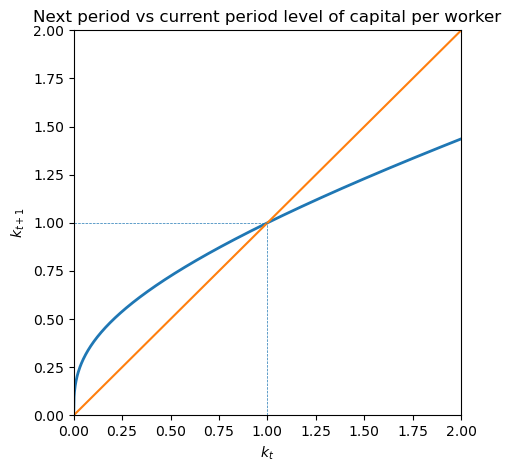


Steady state level of capital per worker = 1.0


In [20]:
# Parameter values (some of them are exaggerated to make the plot easier to read)
A_basic = 1
alpha_basic = 1/3
delta_basic = 0.75
n_basic = 0.05
s_basic = 0.8

# Production function in intensive form
def f_basic(k):
    return k**alpha_basic

# Function for k_{t+1}
def k_next_basic(k):
    return ( s_basic*A_basic*f_basic(k) + (1-delta_basic)*k ) / (1+n_basic)

# Plot range
k_ss_basic = ((s_basic*A_basic)/(delta_basic+n_basic))**(1/(1-alpha_basic))
kk = np.linspace(0, 2*k_ss_basic, 1000)

# Make "square" plot
plt.subplots(figsize = (5, 5))

# Plot k_{t+1} function as well as k_{t+1}=k_{t} line
plt.plot(kk, k_next_basic(kk), lw=2)
plt.plot(kk, kk)

plt.hlines(k_ss_basic, 0, k_ss_basic, linestyle='dashed', lw=0.5)
plt.vlines(k_ss_basic, 0, k_ss_basic, linestyle='dashed', lw=0.5)

plt.title('Next period vs current period level of capital per worker')
plt.xlabel('$k_{t}$')
plt.ylabel('$k_{t+1}$')

plt.show()

print('')
print('Steady state level of capital per worker =', k_ss_basic)

From the plot we can easily see that there is a level of $k$ for which the next period and current period level of capital are the same. We will call this level a **steady state** level of capital per worker, and we will denote it with $k^{*}$. The properties of the neoclassical production function guarantee that there is only one, positive level of $k^{*}$.

Let us find the expression for the steady state level of capital per worker under the Cobb-Douglas production function, by setting $k_{t+1} = k_{t} = k^{*}$:

\begin{align}
\left( 1+n \right) k^{*} &= s \bar{A} \left( k^{*} \right)^{\alpha} + \left( 1-\delta \right) k^{*} \\
\left( \delta+n \right) k^{*} &= s \bar{A} \left( k^{*} \right)^{\alpha} \\
\left( k^{*} \right)^{1-\alpha} &= \frac{s \bar{A}}{\delta+n} \\
k^{*} &= \left( \frac{s \bar{A}}{\delta+n} \right)^{1/(1-\alpha)}
\end{align}

We can also obtain the steady state level of output per worker:

\begin{align}
y^{*} = f \left( k^{*} \right) = \bar{A} \left( k^{*} \right)^{\alpha} = 
\bar{A} \left( \frac{s \bar{A}}{\delta+n} \right)^{\alpha/(1-\alpha)}
\end{align}

It is also useful to take a look at the dynamics of capital per worker, to see how a steady state can be reached:

\begin{align}
k_{t+1} &= \frac{ s f \left( k_{t} \right) + \left( 1-\delta \right) k_{t} }{1+n} \qquad | \quad - k_{t} \\
k_{t+1} - k_{t} &= \frac{ s f \left( k_{t} \right) - \left( \delta + n \right) k_{t} }{1+n} \\
\Delta k_{t+1} &= \frac{ s f \left( k_{t} \right) - \left( \delta + n \right) k_{t} }{1+n} \qquad | \quad : k_{t} \\
\frac{\Delta k_{t+1}}{k_{t}} &= \frac{ s f \left( k_{t} \right) / k_{t} - \left( \delta + n \right) }{1+n}
\end{align}

The above formula gives the expression for the rate of growth of capital per worker. Let us plot the result below (again assuming Cobb-Douglas production function).

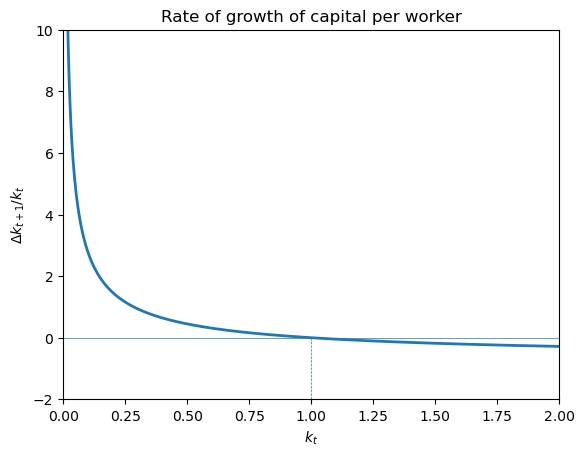

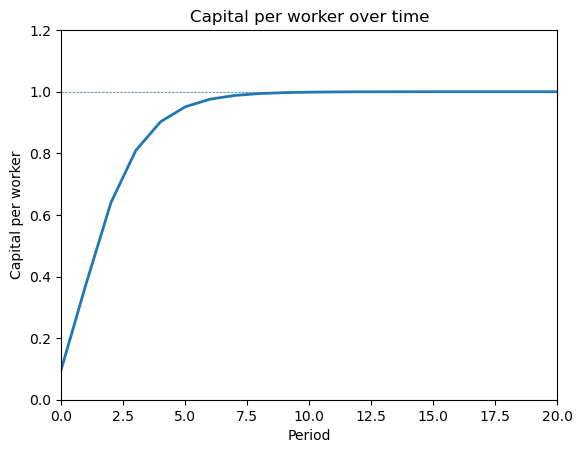

In [21]:
# Plot Δk_{t+1}/k_{t} function
def Δk_k(k):
    return ( s_basic*A_basic*f_basic(k)/k - (delta_basic+n_basic) ) / (1+n_basic)

plt.plot(kk[1:], Δk_k(kk[1:]), lw=2)
plt.hlines(0, 0, 2*k_ss_basic, lw=0.5)
plt.vlines(k_ss_basic, -2, 0, linestyle='dashed', lw=0.5)

plt.ylim(-2, 10)

plt.title('Rate of growth of capital per worker')
plt.xlabel('$k_{t}$')
plt.ylabel(r'$\Delta k_{t+1} / k_{t}$')

plt.show()

# Plot k over time, assuming that k_0 < k_ss
T = 1+20
k_t = np.zeros(T)
k_0 = 0.1 * k_ss_basic
k_t[0] = k_0

for t in range(T-1):
    k_t[t+1] = k_next_basic(k_t[t])
    
plt.plot(k_t, lw=2)

plt.hlines(k_ss_basic, 0, T-1, linestyle='dashed', lw=0.5)

plt.ylim(0, 1.2)

plt.title('Capital per worker over time')
plt.xlabel('Period')
plt.ylabel('Capital per worker')

plt.show()

### Model predictions

Recall the expression for the steady state level of output per worker (assuming Cobb-Douglas production function):

\begin{align}
y^{*} = f \left( k^{*} \right) = \bar{A} \left( k^{*} \right)^{\alpha} = 
\bar{A} \left( \frac{s \bar{A}}{\delta+n} \right)^{\alpha/(1-\alpha)}
\end{align}

As can be easily seen above, the model predicts that:
- countries with high saving / investment rate $s$ and technology level $\bar{A}$ will have higher levels of steady state capital and output per worker
- countries with high depreciation rate $\delta$ and population growth rate $n$ will have lower levels of steady state capital and output per worker

Let us now take a look at the data to see whether the model's predictions are verified.

In [22]:
# Explicit year window; no implicit averaging beyond the endpoint.
rows = []
for country in countries:
    period = pwt.loc[country].loc[START_YEAR:END_YEAR]
    final = period.loc[END_YEAR]
    rows.append({'country': country,
                 's': 100 * period['csh_i'].mean(),
                 'n': 100 * period['pop'].pct_change(fill_method=None).mean(),
                 'y': final['rgdpo'] / final['emp'] if final['emp'] > 0 else np.nan,
                 'N': final['pop']})
dta = pd.DataFrame(rows).set_index('country').replace([np.inf, -np.inf], np.nan)
print('Missing values:', dta.isna().sum().to_dict())
s, n, y, N = (dta[col] for col in ['s', 'n', 'y', 'N'])
dta.head()


Missing values: {'s': 0, 'n': 0, 'y': 6, 'N': 0}


,s,n,y,N
country,,,,
Aruba,35.339317,1.153860,100607.843750,0.107939
Angola,33.301067,3.527582,13160.803711,36.749906
Anguilla,55.594742,1.585426,NaN,0.014410
Albania,20.108229,0.488243,38390.242188,2.811655
United Arab Emirates,35.445464,7.124236,131086.984375,10.642081


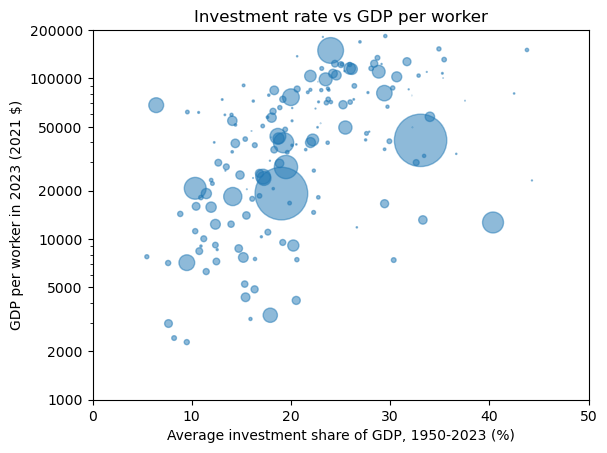

In [23]:
# Investment rate vs GDP per worker
plt.scatter(s, y, s=N, alpha=0.5)

plt.yscale('log')

plt.yticks([1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000],
           [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000])

plt.xlim(0, 50)
plt.ylim(1e3, 2e5)

plt.title('Investment rate vs GDP per worker')
plt.xlabel('Average investment share of GDP, 1950-2023 (%)')
plt.ylabel(r'GDP per worker in 2023 (2021 \$)')

plt.show()

In [24]:
investment_rate = dta["s"]
gdp_per_worker = dta["y"]
correlation = investment_rate.corr(gdp_per_worker)

print(correlation)

0.31439340859085135


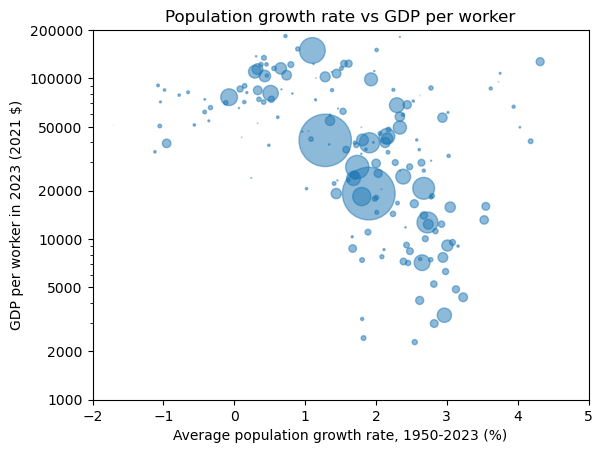

In [25]:
# Population growth rate vs GDP per worker
plt.scatter(n, y, s=N, alpha=0.5)

plt.yscale('log')

plt.yticks([1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000],
           [1000, 2000, 5000, 10000, 20000, 50000, 100000, 200000])

plt.xlim(-2, 5)
plt.ylim(1e3, 2e5)

plt.title('Population growth rate vs GDP per worker')
plt.xlabel('Average population growth rate, 1950-2023 (%)')
plt.ylabel(r'GDP per worker in 2023 (2021 \$)')

plt.show()

In [26]:
population_growth = dta["n"]
correlation = population_growth.corr(gdp_per_worker)

print(correlation)

-0.25806885128640905


So it seems that the model correctly predicts the sign of the relationships.

However, at this stage the model cannot explain the continued increase in GDP per capita in the developed countries, as in the steady state, by definition, the rate of growth of capital per worker, as well as output per worker, is exactly 0.

This actually has profound consequences for growth theory: capital accumulation cannot be the mechanism responsible for long-run growth! Therefore, to explain the continued growth in GDP per capita of developed countries (see below), we need to expand our analysis and allow for improvements in technology.

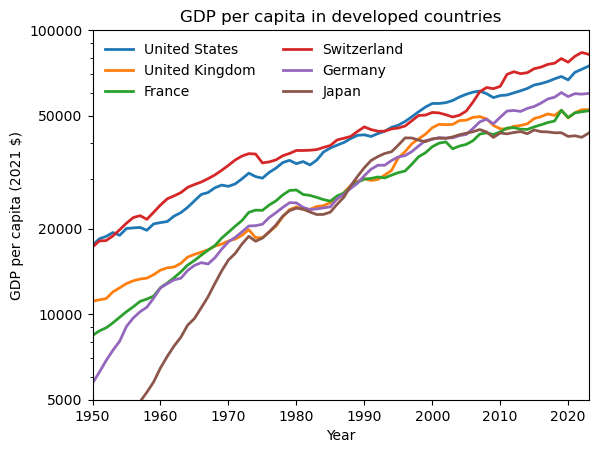

In [27]:
# Plot of GDP per capita of selected developed countries

(pwt.loc['United States']['rgdpe']/pwt.loc['United States']['pop']).plot(lw=2, label='United States')
(pwt.loc['United Kingdom']['rgdpe']/pwt.loc['United Kingdom']['pop']).plot(lw=2, label='United Kingdom')
(pwt.loc['France']['rgdpe']/pwt.loc['France']['pop']).plot(lw=2, label='France')
(pwt.loc['Switzerland']['rgdpe']/pwt.loc['Switzerland']['pop']).plot(lw=2, label='Switzerland')
(pwt.loc['Germany']['rgdpe']/pwt.loc['Germany']['pop']).plot(lw=2, label='Germany')
(pwt.loc['Japan']['rgdpe']/pwt.loc['Japan']['pop']).plot(lw=2, label='Japan')

plt.xlim(START_YEAR, END_YEAR)

plt.yscale('log')
plt.ylim(5000, 100000)

plt.yticks([5000, 10000, 20000, 50000, 100000],
           [5000, 10000, 20000, 50000, 100000])

plt.legend(frameon=False, ncol=2)

plt.title('GDP per capita in developed countries')
plt.xlabel('Year')
plt.ylabel(r'GDP per capita (2021 \$)')

plt.show()

### Balanced growth path

Consider the fundamental equation of a one-sector closed economy:

\begin{align}
K_{t+1} = I_{t} + \left( 1-\delta \right) K_{t}
\end{align}

And rewrite it in difference form:

\begin{align}
\Delta K_{t+1} \equiv K_{t+1} - K_{t} = I_{t} - \delta K_{t} = Y_{t}-C_{t}-\delta K_{t}
\end{align}

It turns out that this equation generates a lot of interesting results.

**Definition: balanced growth path (BGP)**

A balanced growth path is a path $\left\{ Y_{t},K_{t},C_{t}\right\} _{t=0}^{\infty}$ along which the quantities $Y_{t}$, $K_{t}$ and $C_{t}$ are positive and grow at constant (possibly 0) rates, which we denote $g_{Y}$, $g_{K}$ and $g_{C}$, respectively.

**Proposition: equivalence of balanced growth and constancy of key ratios**

Let $\left\{ Y_{t},K_{t},C_{t}\right\} _{t=0}^{\infty}$ be a path along which $Y_{t}$, $K_{t}$, $C_{t}$ and $I_{t}=Y_{t}-C_{t}$
are positive for all $t\geq0$. Then, given the capital accumulation equation, the following holds:

(1) If there is balanced growth, then $g_{Y}=g_{K}=g_{C}=g_{I}$ and the ratios $K/Y$, $C/Y$ and $I/Y$ are constant.

(2) If $K/Y$ and $C/Y$ are constant, then $Y$, $K$, $C$ and $I$ all grow at the same constant rate, i.e. there is not only balanced growth, but balanced growth where $g_{Y}=g_{K}=g_{C}=g_{I}$.

**Proof of (1)**

Consider an economy on a balanced growth path. Then, by definition, $g_{Y}$, $g_{K}$ and $g_{C}$ are constant. If we use the capital accumulation equation, we get the result that $g_{I}=g_{K}$:

\begin{align}
\Delta K_{t+1} & =I_{t}-\delta K_{t}\quad|\quad:K_{t}\\
g_{K}\equiv\frac{\Delta K_{t+1}}{K_{t}} & =\frac{I_{t}}{K_{t}}-\delta\\
\frac{I_{t}}{K_{t}} & =g_{K}+\delta
\end{align}

Since the right hand side of the above equation is constant, then the $I/K$ ratio is constant and that means that the rates of growth of $I$ and $K$ have to be identical.

Focus now on the national accounting relationship:

\begin{align}
Y_{t} = C_{t} + I_{t} \quad \to \quad \Delta Y_{t+1} = \Delta C_{t+1} + \Delta I_{t+1}
\end{align}

\begin{align}
g_{Y} & \equiv \frac{\Delta Y_{t+1}}{Y_{t}} = \frac{\Delta C_{t+1}}{Y_{t}} + \frac{\Delta I_{t+1}}{Y_{t}} =
\frac{\Delta C_{t+1}}{C_{t}} \cdot \frac{C_{t}}{Y_{t}} + \frac{\Delta I_{t+1}}{I_{t}} \cdot \frac{I_{t}}{Y_{t}} \\
g_{Y} & =g_{C}\frac{C_{t}}{Y_{t}} + g_{I}\frac{Y_{t}-C_{t}}{Y_{t}} = \frac{C_{t}}{Y_{t}}\left(g_{C}-g_{I}\right)+g_{I}\\
g_{Y} & =\frac{C_{t}}{Y_{t}}\left(g_{C}-g_{K}\right)+g_{K}
\end{align}

where in the last line the equality between growth rates of $I$ and $K$ was used.

We have now two possibilities: either $g_{C}=g_{K}$ (and in consequence $g_{Y}=g_{K}$) or $g_{C} \neq g_{K}$.

Let us assume that $g_{C} \neq g_{K}$. Then we can rewrite the above expression as:

\begin{align}
\frac{C_{t}}{Y_{t}}=\frac{g_{Y}-g_{K}}{g_{C}-g_{K}}
\end{align}

The right hand side contains only growth rates, which are constant by the definition of the BGP. That means that the $C/Y$ ratio is constant as well, and $g_{C}=g_{Y}$. But this implies that the right hand side is equal to 1 and $C_{t}=Y_{t}$, which contradicts our assumption that $I_{t}=Y_{t}-C_{t}$ is positive.

That means that the assumption $g_{C} \neq g_{K}$ was wrong and $g_{C}=g_{K}$. This also implies that $g_{Y}=g_{K}=g_{I}=g_{C}$.

**Proof of (2)**

Suppose that $K/Y$ and $C/Y$ are constant. Then $g_{Y}=g_{K}=g_{C}$ and as a consequence ($I/Y=1-C/Y$) $g_{Y}=g_{I}=g_{K}$. Now we need to show that the growth rates are also constant. To that end we use the capital accumulation equation:

\begin{align}
\Delta K_{t+1} & =I_{t}-\delta K_{t}\quad|\quad:K_{t}\\
g_{K} & =\frac{I_{t}}{K_{t}}-\delta
\end{align}

Since $g_{I}=g_{K}$ then $I/K$ is constant and in consequence $g_{K}$ and all other key growth rates are constant.

Note that (1) means that any economy on a balanced growth path has to generate constant key ratios. (2) ensures that if we observe constant ratios, the economy is on a balanced growth path.

Let us now check whether the United States economy is on its balanced growth path.

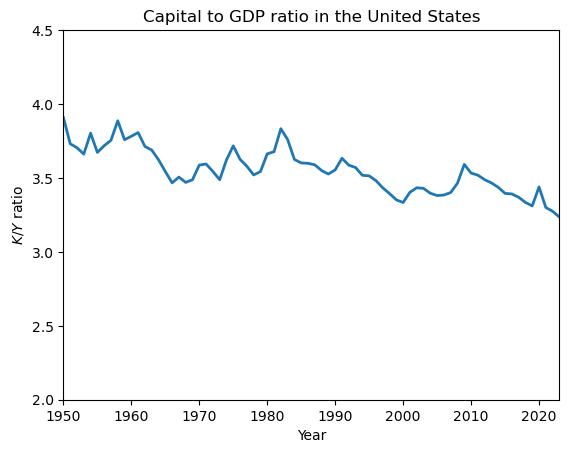

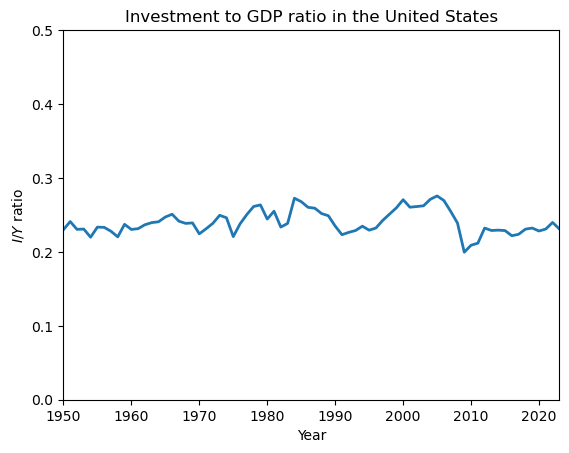

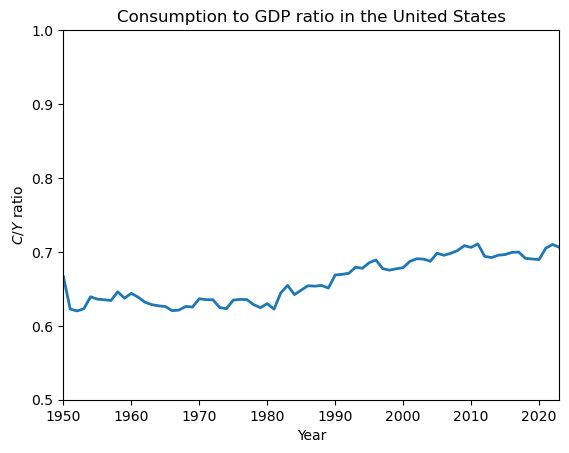

In [28]:
# Capital to GDP ratio in the United States
(pwt.loc['United States']['cn']/pwt.loc['United States']['cgdpo']).plot(lw=2)

plt.xlim(START_YEAR, END_YEAR)
plt.ylim(2, 4.5)

plt.title('Capital to GDP ratio in the United States')
plt.xlabel('Year')
plt.ylabel('$K/Y$ ratio')

plt.show()

# Investment to GDP ratio in the United States
pwt.loc['United States']['csh_i'].plot(lw=2)

plt.xlim(START_YEAR, END_YEAR)
plt.ylim(0, 0.5)

plt.title('Investment to GDP ratio in the United States')
plt.xlabel('Year')
plt.ylabel('$I/Y$ ratio')

plt.show()

# Consumption to GDP ratio in the United States
pwt.loc['United States']['csh_c'].plot(lw=2)

plt.xlim(START_YEAR, END_YEAR)
plt.ylim(0.5, 1)

plt.title('Consumption to GDP ratio in the United States')
plt.xlabel('Year')
plt.ylabel('$C/Y$ ratio')

plt.show()

In the United States, the investment-to-output ratio ($I/Y$) has remained broadly stable since 1950, while the capital-to-output ratio ($K/Y$) has shown a downward trend since the early 2010s. The consumption-to-output ratio ($C/Y$) has generally increased since the 1980s. The decline in $K/Y$ may be linked to higher depreciation rates and productivity growth, while the increase in $C/Y$ has coincided with persistent trade deficits.

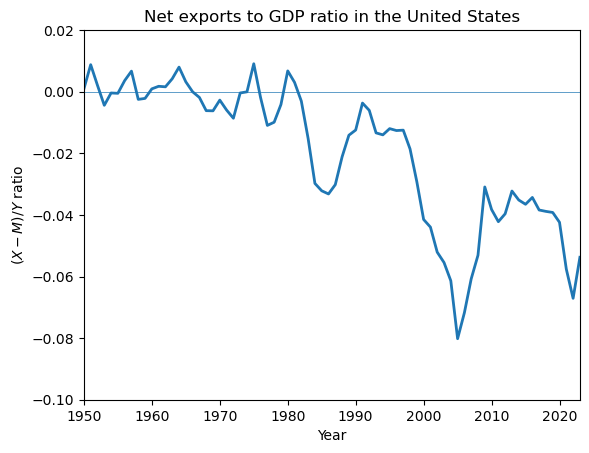

In [29]:
# Net exports to GDP ratio in the United States
(pwt.loc['United States']['csh_x']+pwt.loc['United States']['csh_m']+pwt.loc['United States']['csh_r']).plot(lw=2)
plt.hlines(0, START_YEAR, END_YEAR, lw=0.5)

plt.xlim(START_YEAR, END_YEAR)

plt.title('Net exports to GDP ratio in the United States')
plt.xlabel('Year')
plt.ylabel('$(X-M)/Y$ ratio')

plt.show()

### Technological progress

There are at least three possibilities in how technological progress might manifest itself in our production function. Let $\tilde{F}$ denote the "true" production function and $\tilde{A}$ the "true" form of technological progress:

- Hicks-neutral: technology acts as a multiplicative constant: $\tilde{F}\left(K_{t},L_{t},\tilde{A}_{t}\right)=A_{t}\cdot F\left(K_{t},L_{t}\right)$

- Solow-neutral: technology increases productivity of capital: $\tilde{F}\left(K_{t},L_{t},\tilde{A}_{t}\right)=F\left(A_{t}\cdot K_{t},L_{t}\right)$

- Harrod-neutral: technology increases productivity of labor: $\tilde{F}\left(K_{t},L_{t},\tilde{A}_{t}\right)=F\left(K_{t},A_{t}\cdot L_{t}\right)$

Obviously the technological progress might manifest itself as a combination of the above possibilities: $\tilde{F}\left(K_{t},L_{t},\tilde{A}_{t}\right)=A_{F,t}\cdot F\left(A_{K,t}\cdot K_{t},A_{L,t}\cdot L_{t}\right)$

Despite all of the above forms seem ex ante plausible, balanced growth requires that the "true" production function has a representation of the Harrod-neutral form. Note that it does not mean that literally all technological progress directly increases labor productivity, just that the "true" production function can be rewritten in the required functional form.

**Theorem: [Uzawa's (1961)](http://www.jstor.org/stable/2295709) balanced growth path theorem**

Let $\left\{ Y_{t},K_{t},C_{t}\right\} _{t=0}^{\infty}$, where $0<C_{t}<Y_{t}$ for all $t\geq0$ be a path satisfying the capital accumulation equation. Suppose also that $\tilde{F}\left(K_{t},L_{t},\tilde{A}_{t}\right)$ exhibits constant returns to scale in $K$ and $L$ and worker population grows at a rate $n$ such that $L_{t}=L_{0}\cdot\exp\left(n \cdot t\right)$.

Then a necessary condition for this path to be a balanced growth path is that along the path it holds that:

\begin{align}
Y_{t}=\tilde{F}\left(K_{t},L_{t},\tilde{A}_{t}\right)=F\left(K_{t},A_{t}\cdot L_{t}\right)
\end{align}

where $A_{t}=\exp\left(g \cdot t\right)$ with $g \equiv g_{Y}-n$.

**Proof**

Suppose the path $\left\{ Y_{t},K_{t},C_{t}\right\} _{t=0}^{\infty}$ is a balanced growth path. Then $g_{Y}$ and $g_{K}$ are
equal and constant. As a consequence, we can write $Y_{t}=Y_{0}\cdot\exp\left(g_{Y}\cdot t\right)$ and $K_{t}=K_{0}\cdot\exp\left(g_{K}\cdot t\right)$. We then have:

\begin{align}
Y_{t}\cdot e^{-g_{Y}t}=Y_{0}=\tilde{F}\left(K_{0},L_{0},\tilde{A}_{0}\right)=\tilde{F}\left(K_{t}\cdot e^{-g_{K}t},L_{t}\cdot e^{-nt},\tilde{A}_{0}\right)
\end{align}

Because $g_{Y}=g_{K}$ and the function $\tilde{F}$ satifies constant returns to scale, we can rewrite the above equation as:

\begin{align}
Y_{t}=\tilde{F}\left(K_{t}\cdot e^{-g_{K}t}\cdot e^{g_{Y}t},L_{t}\cdot e^{-nt}\cdot e^{g_{Y}t},\tilde{A}_{0}\right)=\tilde{F}\left(K_{t},L_{t}\cdot e^{\left(g_{Y}-n\right)t},\tilde{A}_{0}\right)
\end{align}

Note that in the above formulation $\tilde{A}$ is reduced to a constant $\tilde{A}_{0}$. Therefore, there exists a function $F\left(K,L\right)$ such that:

\begin{align}
Y_{t}=F\left(K_{t},L_{t}\cdot e^{\left(g_{Y}-n\right)t}\right)
\end{align}

which we can rewrite as

\begin{align}
Y_{t}=F\left(K_{t},A_{t}\cdot L_{t}\right)
\end{align}

where $A_{t}=\exp\left[\left(g_{Y}-n\right) t\right]$ and $g=g_{Y}-n$ is the rate of "rewritten" technology growth.

### Solow-Swan model with technological improvements

Accordingly, we will now assume that the production function has the following form:

\begin{align}
Y_{t} = F \left( K_{t}, A_{t} L_{t} \right)
\end{align}

And that technology $A$ improves at a constant rate $g$:

\begin{align}
\frac{A_{t+1}}{A_{t}} = 1+g
\end{align}

Define output per effective labor $\hat{y}$ and capital per effective labor $\hat{k}$:

\begin{align}
\hat{y}_{t} \equiv \frac{Y_{t}}{A_{t} L_{t}} \quad \text{and} \quad \hat{k}_{t} \equiv \frac{K_{t}}{A_{t} L_{t}}
\end{align}

Again use the constant returns to scale property of the neoclassical production function:

\begin{align}
\hat{y}_{t} = \frac{Y_{t}}{A_{t} L_{t}} = \frac{1}{A_{t} L_{t}} \cdot F \left( K_{t}, A_{t} L_{t} \right) = 
F \left( \frac{1}{A_{t} L_{t}} \cdot K_{t}, \frac{1}{A_{t} L_{t}} \cdot A_{t} L_{t} \right) = 
F \left( \hat{k}_{t}, 1 \right) \equiv f \left( \hat{k}_{t} \right)
\end{align}

where now $f$ denotes the production function per effective labor.


Recall the fundamental equation of the model:

\begin{align}
K_{t+1} = s F \left( K_{t}, A_{t} L_{t} \right) + \left( 1-\delta \right) K_{t}
\end{align}

Express it in terms of variables per effective labor:

\begin{align}
K_{t+1} &= s F \left( K_{t}, A_{t} L_{t} \right) + \left( 1-\delta \right) K_{t} \qquad | \quad : A_{t} L_{t} \\
\frac{K_{t+1}}{A_{t} L_{t}} &= s \frac{F \left( K_{t}, A_{t} L_{t} \right)}{A_{t} L_{t}} 
+ \left( 1-\delta \right) \frac{K_{t}}{A_{t} L_{t}} \\
\frac{L_{t+1}}{L_{t}} \cdot \frac{A_{t+1}}{A_{t}} \cdot \frac{K_{t+1}}{A_{t+1} L_{t+1}}  &= s f \left( \hat{k}_{t} \right) 
+ \left( 1-\delta \right) \hat{k}_{t} \\
\left( 1+n \right) \left( 1+g \right) \hat{k}_{t+1}  &= s f \left( \hat{k}_{t} \right) 
+ \left( 1-\delta \right) \hat{k}_{t}
\end{align}

As before, we can find the steady state level of capital per effective labor, assuming a Cobb-Douglas production function:

\begin{align}
F \left( K, AL \right) = K^{\alpha} \left( AL \right)^{1-\alpha} \quad \to \quad 
f \left( \hat{k} \right) = \hat{k}^{\alpha}
\end{align}

\begin{align}
\left( 1+n+g+ng \right) \hat{k}_{t+1} &= s f \left( \hat{k}_{t} \right) + \left( 1-\delta \right) \hat{k}_{t} \\
\left( 1+n+g+ng \right) \hat{k}^{*} &= s \left( \hat{k}^{*} \right)^{\alpha} + \left( 1-\delta \right) \hat{ss}_{t} \\
\left( \delta+n+g+ng \right) \hat{k}^{*} &= s \left( \hat{k}^{*} \right)^{\alpha} \\
\left( \hat{k}^{*} \right)^{1-\alpha} &= \frac{s}{\delta+n+g+ng} \\
\hat{k}^{*} &= \left( \frac{s}{\delta+n+g+ng} \right)^{1/(1-\alpha)} \\
\hat{k}^{*} &\approx \left( \frac{s}{\delta+n+g} \right)^{1/(1-\alpha)}
\end{align}

Where the approximation above utilizes the fact that the product of $n$ and $g$ is very small.

### GDP per worker along the Balanced Growth Path

In the case of positive rate of technologial improvements, even if capital per effective labor converges to the steady state,  output per worker continues to grow (at a rate $g$):

\begin{align}
y_{t} = \frac{Y_{t}}{L_{t}} = A_{t} \cdot \frac{Y_{t}}{A_{t} L_{t}} = A_{t} \cdot \hat{y}_{t} = 
A_{t} \cdot f \left( \hat{k}_{t} \right)
\end{align}

\begin{align}
\frac{\Delta y_{t+1}}{y_{t}} = 
\frac{A_{t+1} \cdot f \left( \hat{k}_{t+1} \right) - A_{t} \cdot f \left( \hat{k}_{t} \right)}
{A_{t} \cdot f \left( \hat{k}_{t} \right)} =
\frac{A_{t+1}}{A_{t}} \cdot \frac{f \left( \hat{k}_{t+1} \right)}{f \left( \hat{k}_{t} \right)} - 1
\end{align}

So along the balanced growth path when $\hat{k}_{t+1} = \hat{k}_{t} = \hat{k}^{*}$:

\begin{align}
g_{y}^{*} = \frac{\Delta y_{t+1}^{*}}{y_{t}^{*}} = \frac{A_{t+1}}{A_{t}} \cdot \frac{f \left( \hat{k}^{*} \right)}{f \left( \hat{k}^{*} \right)} - 1 = \left( 1 + g \right) \cdot 1 - 1 = g
\end{align}

And the value of output per worker along the balanced growth path is equal to:

\begin{align}
y_{t}^{*} = A_{t} \cdot \left( \frac{s}{\delta+n+g} \right)^{\alpha/(1-\alpha)}
\end{align}

If we take the logarithms of the above equation, we get:

\begin{align}
\log y_{t}^{*} &= \log \left( A_{0} \cdot \left( 1+g \right)^{t} \right) + \frac{\alpha}{1-\alpha} \log s 
- \frac{\alpha}{1-\alpha} \log \left( \delta+n+g \right) \\
\log y_{t}^{*} &= \log A_{0} + t \cdot \log \left( 1+g \right) + \frac{\alpha}{1-\alpha} \log s 
- \frac{\alpha}{1-\alpha} \log \left( \delta+n+g \right)
\end{align}

The above equation can be rewritten as an empirical model for a regression:

\begin{align}
\log y_{t} &= a_{0} + a_{1} \log s + a_{2} \log \left( \delta+n+g \right) + \epsilon
\end{align}

where $a_{0}$ is a constant and $\epsilon$ is a country-specific shock to initial technology and the distance from the balanced growth path.

Additionally, one can run a restricted regression:

\begin{align}
\log y_{t} &= a_{0} + a_{1} \left[ \log s - \log \left( \delta+n+g \right) \right] + \epsilon
\end{align}

where:

\begin{align}
a_{1} = -a_{2} = \frac{\alpha}{1-\alpha}
\end{align}

This is the first empirical exercise in [Mankiw, Romer and Weil (1992)](http://www.jstor.org/stable/2118477), which we will replicate below.

In [30]:
# Read in Mankiw, Romer and Weil (1992) data
mrw =pd.read_stata('data/MRW1992.dta')
mrw_countries = mrw['country']
mrw.head()

,country,N,I,O,Y60,Y85,Y_growth,pop_growth,invest,school
0,Algeria,1,1,0,2485.0,4371.0,4.8,2.6,24.100000,4.5
1,Angola,1,0,0,1588.0,1171.0,0.8,2.1,5.800000,1.8
2,Benin,1,0,0,1116.0,1071.0,2.2,2.4,10.800000,1.8
3,Botswana,1,1,0,959.0,3671.0,8.6,3.2,28.299999,2.9
4,Burkina Faso,1,0,0,529.0,857.0,2.9,0.9,12.700000,0.4


In [31]:
# Prepare variables for regression
mrw['y_85'] = np.log(mrw['Y85'])
mrw['s'] = np.log(mrw['invest']/100)
mrw['δ_n_g'] = np.log(0.05+mrw['pop_growth']/100)
mrw['restricted'] = mrw['s'] - mrw['δ_n_g']

In [32]:
# Run regression on the non-oil countries sample
mrw_N = mrw[mrw['N']==1]
print(r'\t Non-oil countries')
mrw_results = smf.ols('y_85 ~ s + δ_n_g', data=mrw_N).fit()
print(mrw_results.summary())

\t Non-oil countries
                            OLS Regression Results                            
Dep. Variable:                   y_85   R-squared:                       0.601
Model:                            OLS   Adj. R-squared:                  0.592
Method:                 Least Squares   F-statistic:                     71.51
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           1.13e-19
Time:                        07:44:07   Log-Likelihood:                -101.04
No. Observations:                  98   AIC:                             208.1
Df Residuals:                      95   BIC:                             215.8
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      5.4299      1.58

In [33]:
# Run restricted regression on the non-oil countries sample
print(r'\t Restricted regression')
print(r'\t Non-oil countries')
mrw_results_restricted = smf.ols('y_85 ~ restricted', data=mrw_N).fit()
print(mrw_results_restricted.summary())
print('')
print('Implied α =', mrw_results_restricted.params['restricted']/(1+mrw_results_restricted.params['restricted']))
print('')
print('Test of restriction p-value =', mrw_results.compare_f_test(mrw_results_restricted)[1])

\t Restricted regression
\t Non-oil countries
                            OLS Regression Results                            
Dep. Variable:                   y_85   R-squared:                       0.597
Model:                            OLS   Adj. R-squared:                  0.593
Method:                 Least Squares   F-statistic:                     142.4
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           1.13e-20
Time:                        07:44:07   Log-Likelihood:                -101.46
No. Observations:                  98   AIC:                             206.9
Df Residuals:                      96   BIC:                             212.1
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Interc

So it seems that our empirical model is quite successful, as it is able to explain around 60% of total variation in GDP per worker across countries with the observables suggested by the theory.

There is however a problem: implied level of $\alpha$ is well above $0.5$, whereas economists usually think that $\alpha \in [0.3, 0.4]$.

Let us turn back to theory and see whether we can construct a way to recover $\alpha$ from other data.

### Firms' profit maximization problem

Firms choose employment $L$ and rent such levels of capital $K$ which maximizes their profits:

\begin{align}
\max_{K, L} \quad & \Pi = Y - w L - r^{k} K \\
\text{subject to} \quad & Y = K^{\alpha} \left( AL \right)^{1-\alpha}
\end{align}

where $w$ is real wage and $r^{k}$ is the rental rate of capital. Rewrite the problem:

\begin{align}
\max_{K, L} \quad & \Pi = K^{\alpha} \left( AL \right)^{1-\alpha} - w L - r^{k} K
\end{align}

Derive the first order conditions:

\begin{align}
\frac{\partial \Pi}{\partial K} &= \alpha K^{\alpha-1} \left( AL \right)^{1-\alpha} - r^{k} = 0
\quad \quad \,\,\,\, \to \quad r^{k} = \alpha \frac{Y}{K} \\
\frac{\partial \Pi}{\partial L} &= \left( 1-\alpha \right) K^{\alpha} A^{1-\alpha} L^{-\alpha} - w = 0
\quad \to \quad w = \left( 1-\alpha \right) \frac{Y}{L}
\end{align}

Now take a look at the share of labor income in GDP:

\begin{align}
\frac{wL}{Y} = \frac{\left( 1-\alpha \right) \dfrac{Y}{L} \cdot L}{Y} = 1-\alpha
\end{align}

We can see that we can recover the value of $\alpha$ via the following formula:

\begin{align}
\alpha = 1 - \frac{wL}{Y}
\end{align}

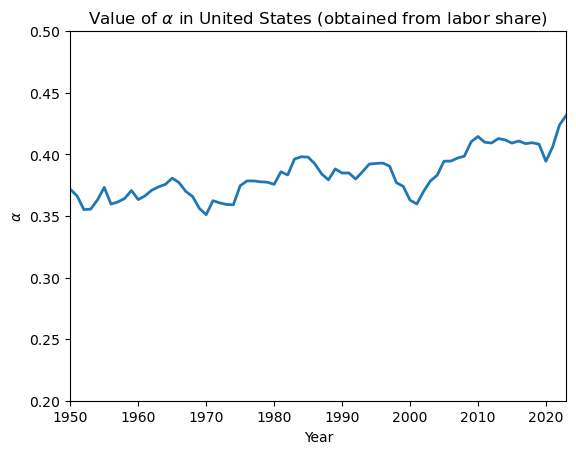

In [34]:
(1-pwt.loc['United States']['labsh']).plot(lw=2)

plt.xlim(START_YEAR, END_YEAR)
plt.ylim(0.2, 0.5)

plt.title(r'Value of $\alpha$ in United States (obtained from labor share)')
plt.xlabel('Year')
plt.ylabel(r'$\alpha$')

plt.show()

Therefore, MRW consider the following modification of the Solow-Swan model:

- Production function:

\begin{align}
Y = K^{\alpha} H^{\beta} \left( AL \right)^{1-\alpha-\beta}
\end{align}

where $H$ denotes the stock of human capital.

- Balanced growth path level of GDP per worker:

\begin{align}
\log y_{t}^{*} = \log A_{0} + t \cdot \log \left( 1+g \right) - \frac{\alpha+\beta}{1-\alpha-\beta} \log \left( \delta+n+g \right)
+ \frac{\alpha}{1-\alpha-\beta} \log s_{k} + \frac{\beta}{1-\alpha-\beta} \log s_{h}
\end{align}

where $s_{k}$ and $s_{h}$ denote saving/investment rates in physical and human capital

In [35]:
# Add in log of s_h
mrw['s_h'] = np.log(mrw['school'])

# Run regression on the non-oil countries sample
print(r'\t Non-oil countries')
mrw_h_results = smf.ols('y_85 ~ s + δ_n_g + s_h', data=mrw[mrw['N']==1]).fit()
print(mrw_h_results.summary())

\t Non-oil countries
                            OLS Regression Results                            
Dep. Variable:                   y_85   R-squared:                       0.786
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     114.8
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           2.54e-31
Time:                        07:44:07   Log-Likelihood:                -70.576
No. Observations:                  98   AIC:                             149.2
Df Residuals:                      94   BIC:                             159.5
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      3.8305      1.18

In [36]:
# Add in restrictions
mrw['restricted_h'] = mrw['s_h'] - mrw['δ_n_g']
mrw_N = mrw[mrw['N']==1]

# Run restricted regression on the non-oil countries sample
print(r'\t Restricted regression')
print(r'\t Non-oil countries')
mrw_h_results_restricted = smf.ols('y_85 ~ restricted + restricted_h', data=mrw_N).fit()
print(mrw_h_results_restricted.summary())

α_β = ((mrw_h_results_restricted.params['restricted']+mrw_h_results_restricted.params['restricted_h'])/
       (1+mrw_h_results_restricted.params['restricted']+mrw_h_results_restricted.params['restricted_h']))

print('')
print('Implied α =', mrw_h_results_restricted.params['restricted'] * (1-α_β))
print('Implied β =', mrw_h_results_restricted.params['restricted_h'] * (1-α_β))
print('')
print('Test of restriction p-value =', mrw_h_results.compare_f_test(mrw_h_results_restricted)[1])

\t Restricted regression
\t Non-oil countries
                            OLS Regression Results                            
Dep. Variable:                   y_85   R-squared:                       0.784
Model:                            OLS   Adj. R-squared:                  0.779
Method:                 Least Squares   F-statistic:                     172.3
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           2.47e-32
Time:                        07:44:07   Log-Likelihood:                -70.963
No. Observations:                  98   AIC:                             147.9
Df Residuals:                      95   BIC:                             155.7
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                   coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------
In

And as you can see, the modification places the value of $\alpha$ back in the range of plausible values. 

Moreover, the model can now explain around 78% of total variation of GDP per capita across countries.


### Convergence
The model can also be used to evaluate the speed of convergence across countries. While deriving the formula is quite tedious, the end result is quite straightforward:

\begin{align}
\frac{\Delta y_{t+1}}{y_{t}} \approx \underbrace{ \left( \delta+n+g \right) \left( 1-\alpha-\beta \right) }_{\lambda} 
\cdot [\log y_{t}^{*} - \log y_{t}]
\end{align}

The above formula implies that the growth rate of GDP per worker in a country is a positive function of its distance to its balanced growth path level. The value of $\lambda$ dictates how fast a country converges. For example, if $\lambda=0.02$ then a country closes half of the distance between the initial and BGP level of GDP in around 35 years.

The equation can be rewritten into a form that is easy to run a regression on:

\begin{align}
\log y_{t} - \log y_{0} = \left( 1-e^{-\lambda t} \right) \left[ \frac{\alpha}{1-\alpha-\beta} \log s_{k}
+ \frac{\beta}{1-\alpha-\beta} \log s_{h}
- \frac{\alpha+\beta}{1-\alpha-\beta} \log \left( \delta+n+g \right)
- \log y_{0} \right]
\end{align}

where $\log y_{0}$ denotes an initial level of GDP per worker.

In [37]:
# Add in log of initial GDP per worker
mrw['y_60'] = np.log(mrw['Y60'])

# Add in log-difference of levels of GDP per worker
mrw['y_85_60'] = mrw['y_85'] - mrw['y_60']

mrw_N = mrw[mrw['N']==1]

# Run regressions
print(r'\t Non-oil countries')
mrw_results_N = smf.ols('y_85_60 ~ y_60 + s + δ_n_g + s_h', data=mrw_N).fit()
print(mrw_results_N.summary())
print('')
print('Implied λ =', np.log(1+mrw_results_N.params['y_60'])/(-25))

print('')
print(r'\t Intermediate countries')
mrw_results_I = smf.ols('y_85_60 ~ y_60 + s + δ_n_g + s_h', data=mrw[mrw['I']==1]).fit()
print(mrw_results_I.summary())
print('')
print('Implied λ =', np.log(1+mrw_results_I.params['y_60'])/(-25))


print('')
print(r'\t OECD countries')
mrw_results_O = smf.ols('y_85_60 ~ y_60 + s + δ_n_g + s_h', data=mrw[mrw['O']==1]).fit()
print(mrw_results_O.summary())
print('')
print('Implied λ =', np.log(1+mrw_results_O.params['y_60'])/(-25))

\t Non-oil countries
                            OLS Regression Results                            
Dep. Variable:                y_85_60   R-squared:                       0.485
Model:                            OLS   Adj. R-squared:                  0.463
Method:                 Least Squares   F-statistic:                     21.94
Date:                Thu, 08 Oct 2026   Prob (F-statistic):           8.99e-13
Time:                        07:44:07   Log-Likelihood:                -26.952
No. Observations:                  98   AIC:                             63.90
Df Residuals:                      93   BIC:                             76.83
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.9572      0.77

For the developed countries, the theoretical model would predict that $\lambda \approx 0.02$ since $\delta+n+g \approx 0.06$ and $1-\alpha-\beta \approx 0.33$. This is exactly the value implied by the regression for the OECD countries.

In the plots below we can see that while there is no unconditional convergence, as poorer countries do not consistently grow faster than richer countries, once we control for observables impacting the steady states of the economies, convergence is evident.

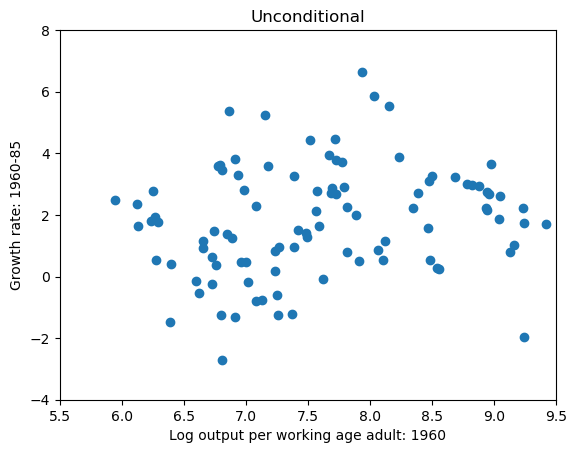

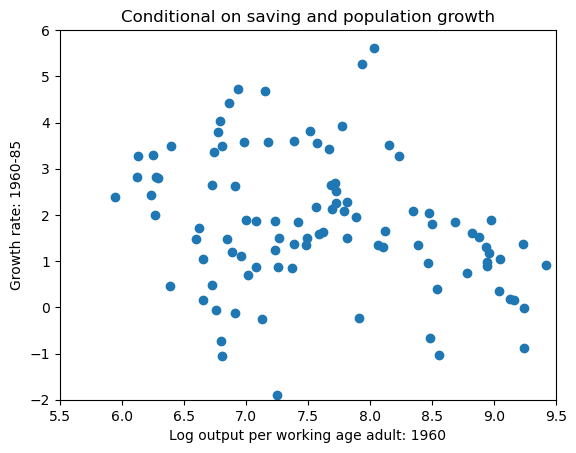

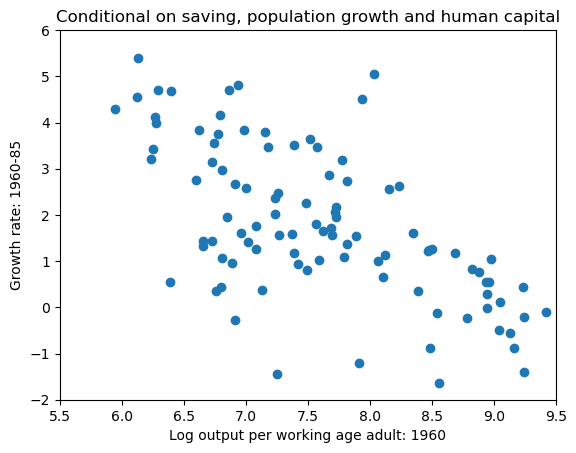

In [38]:
# Convergence plots

par = mrw_results_N.params

# plt.scatter(mrw_N['y_60'], 100*((mrw_N['Y85']/mrw_N['Y60'])**(1/25)-1))
plt.scatter(mrw_N['y_60'], 100*mrw_N['y_85_60']/25)

plt.title('Unconditional')
plt.xlabel('Log output per working age adult: 1960')
plt.ylabel('Growth rate: 1960-85')

plt.show()

###
plt.scatter(mrw_N['y_60'], 
            100/25*(mrw_N['y_85_60']
                    -par['s']*(mrw_N['s']-mrw_N['s'].mean())
                    -par['δ_n_g']*(mrw_N['δ_n_g']-mrw_N['δ_n_g'].mean())))

plt.title('Conditional on saving and population growth')
plt.xlabel('Log output per working age adult: 1960')
plt.ylabel('Growth rate: 1960-85')

plt.show()

###
plt.scatter(mrw_N['y_60'], 
            100/25*(mrw_N['y_85_60']
                    -par['s']*(mrw_N['s']-mrw_N['s'].mean())
                    -par['δ_n_g']*(mrw_N['δ_n_g']-mrw_N['δ_n_g'].mean())
                    -par['s_h']*(mrw_N['s_h']-mrw_N['s_h'].mean())))

plt.title('Conditional on saving, population growth and human capital')
plt.xlabel('Log output per working age adult: 1960')
plt.ylabel('Growth rate: 1960-85')

plt.show()

### Homework 1. Part A: Plots

Plot the histogram of average growth rates between 1980 and 2020. 
Differentiate between developed, catching-up, and lagging behind countries.
Make sure the plot title, axis titles, and legend reflect the correct information. Briefly comment on the results

### Homework 1. Part B: Data Analysis

Construct a dataset with one row per country and GDP per capita in both 2000 and 2022. Exclude countries with missing, nonfinite, or nonpositive values in either year. 
1. Report how many countries were excluded and how many remain.
2. Report median GDP per capita and the 10th and 90th percentiles for each year.
3. Plot the distributions of log GDP per capita in 2000 and 2022. Use the same histogram bin edges for both years.
4. Calculate the ratio of the 90th percentile to the 10th percentile in each year.
5. Briefly explain how typical income and income dispersion changed. Each country should receive equal weight.

### Homework 1. Part C: Solow Model

**Task 1**: Assume the following parameters for the country ABC:

\begin{align}
A = 1 \\
α = 1/3 \\
δ = 0.4 \\
n = 0.05 \\
s = 0.5 \\
\end{align}

Calculate the steady-state value of the capital per worker (only up to 4 decimal points). Assume that initial capital per worker is 0.25. Draw a plot by putting time (period) on x-axis and capital per worker on y-axis. Set maximum period to 50. Show the initial level of capital per worker, transition period, and steady-state level of capital per worker clearly.

**Important**: The following tasks are independent of each other!

**Task 2**: Assume now that country ABC is at steady-state and we are in period 30. After 10 years being at steady-state, suddenly people become more prudent and saving rate increased from 0.5 to 0.6 permanently in country ABC. Calculate the new steady-state level of capital per worker in the country ABC (only up to 4 decimal points). On the same plot you drew in Task 1, et maximum period to 100 and show the new steady-state level of capital per worker? Did it increase or decrease? Why? What is the economic intuition behind the change in steady-state level of capital per worker after an increase in saving rate?

**Task 3**: Assume now that country ABC is at initial steady-state you calculated in Task 1. After 10 years reaching steady-state, the war happens and country ABC loses 40% of its capital per worker. However, all parameter values are same as in Task 1 (saving rate is 0.5). Calculate the new steady-state level of capital per worker in the country ABC. On the same plot you drew in Task 1, set maximum period to 100 and show the new steady-state level of capital per worker? Did it increase or decrease or not change? Why or why not? Show the initial level of capital per worker, transition period, and steady-state level of capital per worker clearly.

Hint: you may want to benefit from the codes in the section after homeworks: Optional - Analysis of Saving Rate.

### Homework 1. Part D: replication of MRW results using PWT 11.0

In [39]:
# Match country names explicitly. Report unavailable countries.
country_aliases = {
    'CentralAfr. Rep.': 'Central African Republic', 'Congo, Peop. Rep.': 'Congo',
    'Ivory Cost': "Côte d'Ivoire", 'S. Africa': 'South Africa',
    'Tanzania': 'U.R. of Tanzania: Mainland', 'Zaire': 'D.R. of the Congo',
    'Burma': 'Myanmar', 'Hong Kong': 'China, Hong Kong SAR',
    'Korea, Rep. of': 'Republic of Korea', 'Syrian Arab Rep.': 'Syrian Arab Republic',
    'Germany, Fed. Rep.': 'Germany', 'Dominican Rep.': 'Dominican Republic',
    'Trinidad & Tobago': 'Trinidad and Tobago', 'Bolivia': 'Bolivia (Plurinational State of)',
    'Venezuela': 'Venezuela (Bolivarian Republic of)'}
# PWT 11.0 uses a revised name for Turkey; use its stable country code.
country_aliases['Turkey'] = pwt.loc[pwt['countrycode'].eq('TUR')].index.get_level_values('country')[0]
available = set(pwt.index.get_level_values('country'))
matched, not_found = [], []
for country in mrw.loc[mrw['N'].eq(1), 'country']:
    candidate = country_aliases.get(country, country)
    if candidate in available:
        matched.append(candidate)
    else:
        not_found.append(country)
print('Countries unavailable in PWT:', not_found)


Countries unavailable in PWT: ['Papua New Guinea']


In [40]:
# Preserve order while removing duplicate matched names.
mrw_pwt_countries = list(dict.fromkeys(matched))


In [41]:
assert len(mrw_pwt_countries) == len(set(mrw_pwt_countries))


In [42]:
# Construct the replication dataset using the explicit 1985–END_YEAR window.
rows = []
for country in mrw_pwt_countries:
    period = pwt.loc[country].sort_index().loc[1985:END_YEAR]
    first, last = period.loc[1985], period.loc[END_YEAR]
    investment = period['csh_i'].mean()
    growth_term = .05 + period['emp'].pct_change(fill_method=None).mean()
    human_index = period['hc'].mean()
    def positive_log(value):
        return np.log(value) if pd.notna(value) and np.isfinite(value) and value > 0 else np.nan
    def output_per_worker(row):
        return row['rgdpo'] / row['emp'] if pd.notna(row['emp']) and row['emp'] > 0 else np.nan
    rows.append({'country': country, 'y_23': positive_log(output_per_worker(last)),
                 'y_85': positive_log(output_per_worker(first)),
                 's': positive_log(investment), 'δ_n_g': positive_log(growth_term),
                 's_h': positive_log(10 * positive_log(human_index))})
mrw_rep_raw = pd.DataFrame(rows).set_index('country').replace([np.inf, -np.inf], np.nan)
mrw_rep_raw['y_23_85'] = mrw_rep_raw['y_23'] - mrw_rep_raw['y_85']
excluded = mrw_rep_raw.index[mrw_rep_raw.isna().any(axis=1)].tolist()
print('Excluded because required values are missing or invalid:', excluded)
mrw_rep = mrw_rep_raw.dropna().copy()
print(f'Replication window: 1985–{END_YEAR}; complete countries: {len(mrw_rep)}')
mrw_rep.head()


Excluded because required values are missing or invalid: ['Chad', 'Somalia']
Replication window: 1985–2023; complete countries: 95


,y_23,y_85,s,δ_n_g,s_h,y_23_85
country,,,,,,
Algeria,10.963898,11.359983,-1.164556,-2.536208,1.887979,-0.396086
Angola,9.484999,8.929098,-1.144811,-2.484417,1.035082,0.555901
Benin,9.323925,8.738811,-1.994986,-2.546256,1.433951,0.585114
Botswana,10.632174,9.761808,-1.376208,-2.492512,2.213175,0.870365
Burkina Faso,8.889307,7.940952,-1.885522,-2.643378,0.244581,0.948355


**Task 1**: run an unrestricted estimation on the replication dataset of the human capital augmented Solow model,
with `y_23` as the dependent variable and `s`, `δ_n_g` and `s_h` as independent variables.
Comment on the coefficient signs and explanatory power of the model.

**Task 2**: run a restricted estimation on the replication dataset of the human capital augmented Solow model,
with `y_23` as the dependent variable, and appropriate restrictions as independent variables.
Comment on the implied values of $\alpha$ and $\beta$.

## Optional - Analysis of Saving Rate

In [43]:
def k_ss_optional(s=0.2, δ=0.05, n=0.01, g=0.02, α=1/3):
    return (s/(δ+n+g+n*g))**(1/(1-α))

def f_optional(k, α=1/3):
    return k**α

In [44]:
def c_star(s=0.2, δ=0.05, n=0.01, g=0.02, α=1/3):
    return (1-s)*f_optional(k_ss_optional(s, δ, n, g, α), α)

def c_k(k, s=0.2, α=1/3):
    return (1-s)*f_optional(k, α)

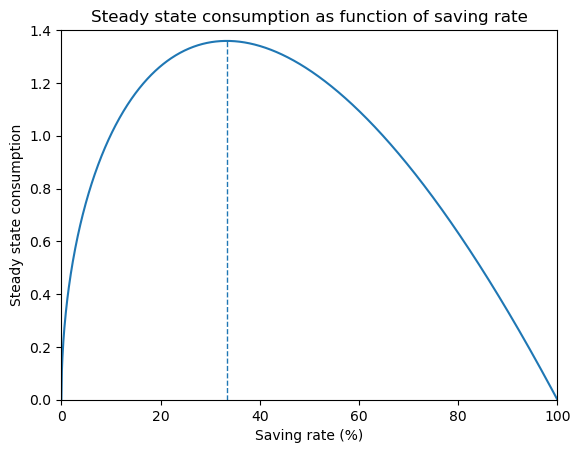

In [45]:
δ=0.05
n=0.01
g=0.02
α=1/3

ss = np.linspace(0, 1, 1000)

plt.plot(100*ss, c_star(ss, δ, n, g, α))
plt.vlines(100*α, 0, c_star(α, δ, n, g, α), lw=1, linestyle='--')

plt.title('Steady state consumption as function of saving rate')
plt.ylabel('Steady state consumption')
plt.xlabel('Saving rate (%)')

plt.show()

In [46]:
def k_next_optional(k, s=0.2, δ=0.05, n=0.01, g=0.02, α=1/3):
    return (s*f_optional(k, α)+(1-δ)*k)/((1+n)*(1+g))

Initial saving rate below golden rule saving rate


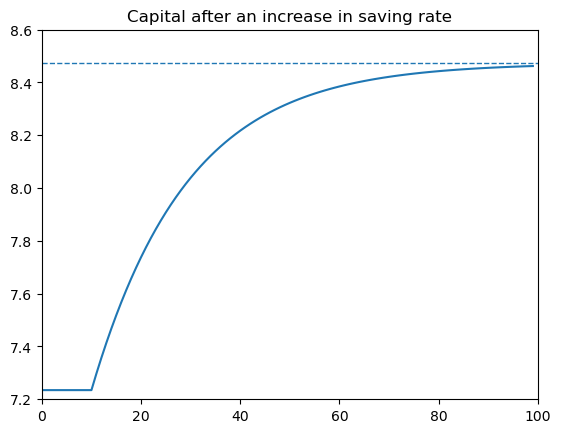

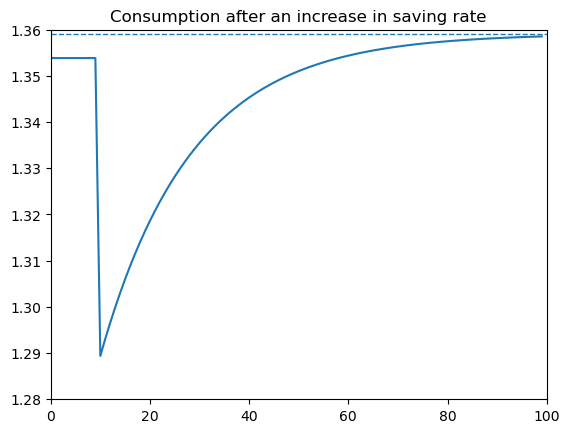

In [47]:
T = 100
k_t = np.zeros(T)
c_t = np.zeros(T)

print('Initial saving rate below golden rule saving rate')

s_old = 0.3
s_GR  = α

k_t[:11] = k_ss_optional(s=s_old)
c_t[:10] = c_k(k_t[:10], s=s_old)
c_t[10] = c_k(k_t[10], s=s_GR)
for t in range(11, T):
    k_t[t] = k_next_optional(k_t[t-1], s=s_GR)
    c_t[t] = c_k(k_t[t], s=s_GR)

plt.plot(k_t)
plt.hlines(k_ss_optional(s=s_GR), 0, T, lw=1, linestyle='--')
plt.title('Capital after an increase in saving rate')
plt.show()

plt.plot(c_t)
plt.hlines(c_star(s=s_GR), 0, T, lw=1, linestyle='--')
plt.title('Consumption after an increase in saving rate')
plt.show()

Initial saving rate above golden rule saving rate


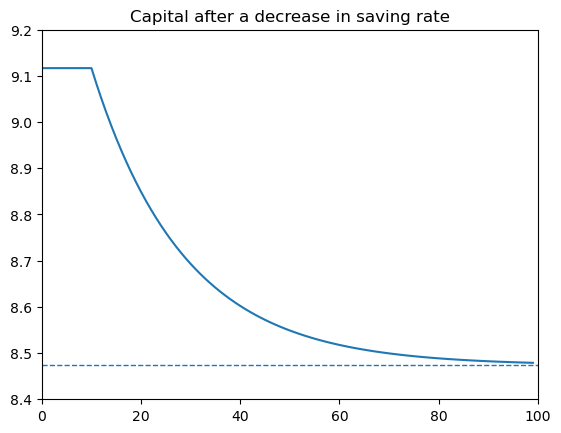

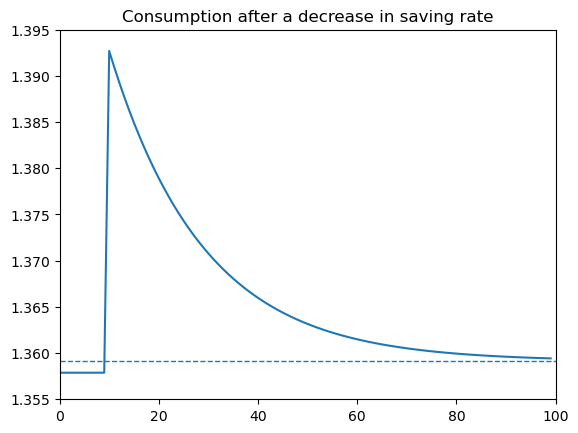

In [48]:
T = 100
k_t = np.zeros(T)
c_t = np.zeros(T)

print('Initial saving rate above golden rule saving rate')

s_old = 0.35
s_GR  = α

k_t[:11] = k_ss_optional(s=s_old)
c_t[:10] = c_k(k_t[:10], s=s_old)
c_t[10] = c_k(k_t[10], s=s_GR)
for t in range(11, T):
    k_t[t] = k_next_optional(k_t[t-1], s=s_GR)
    c_t[t] = c_k(k_t[t], s=s_GR)

plt.plot(k_t)
plt.hlines(k_ss_optional(s=s_GR), 0, T, lw=1, linestyle='--')
plt.title('Capital after a decrease in saving rate')
plt.show()

plt.plot(c_t)
plt.hlines(c_star(s=s_GR), 0, T, lw=1, linestyle='--')
plt.title('Consumption after a decrease in saving rate')
plt.show()

In [49]:
# Keep the country-name table intact for rerunning earlier cells.
pwt_by_code = pwt.reset_index().set_index(['countrycode', 'year']).sort_index()


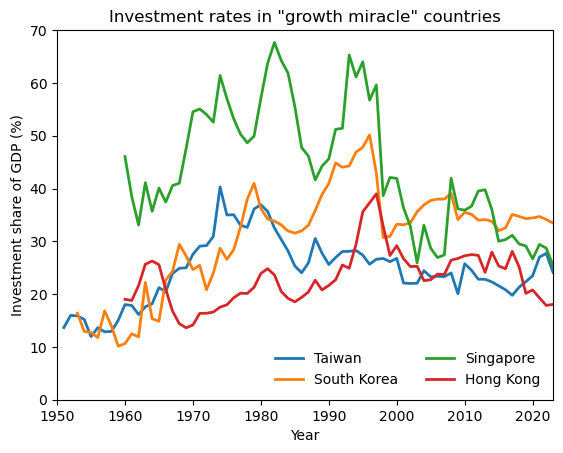

In [50]:
(100*pwt_by_code.loc['TWN']['csh_i']).plot(lw=2, label='Taiwan')
(100*pwt_by_code.loc['KOR']['csh_i']).plot(lw=2, label='South Korea')
(100*pwt_by_code.loc['SGP']['csh_i']).plot(lw=2, label='Singapore')
(100*pwt_by_code.loc['HKG']['csh_i']).plot(lw=2, label='Hong Kong')

plt.xlim(START_YEAR, END_YEAR)
plt.ylim(0, 70)

plt.title('Investment rates in "growth miracle" countries')
plt.xlabel('Year')
plt.ylabel('Investment share of GDP (%)')

plt.legend(loc='lower right', ncol=2, frameon=False)

plt.show()